In [8]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import numpy as np
from sklearn.mixture import GaussianMixture
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

In [9]:
df_reddit = pd.read_csv("reddit_ngrams_analysis.csv")
df_reddit

,Unnamed: 0,post_id,keyword,post_title,post_text,post_date,comments,source_method,post_text_clean,comments_clean,post_length,num_comments_length,year,month,post_lemmas,comment_lemmas,post_title_lemmas,post_content
0,0,1dg7p5a,depression,I wish someone would just...,Just fucking kill me. Shoot me. I wish I could...,2024-06-15 11:54:16,['Life is overall shitty and borderline unbear...,top,fucking kill shoot wish bed fucking wake anymo...,life overall shitty borderline unbearable goin...,834,125,2024,6,"['fucking', 'kill', 'shoot', 'wish', 'bed', 'f...","['life', 'overall', 'shitty', 'borderline', 'u...","['I', 'wish', 'someone', 'would', 'just', '...']",I wish someone would just... Just fucking kill...
1,1,1dga2ht,depression,A friend of mine once described depression as ...,And felt like that is the most apt description...,2024-06-15 14:12:57,['Whenever I was younger and when I was at my ...,top,felt apt description heard feels agree,younger lowest said home got older continued r...,38,145,2024,6,"['feel', 'apt', 'description', 'hear', 'feel',...","['younger', 'lowest', 'say', 'home', 'get', 'o...","['a', 'friend', 'of', 'mine', 'once', 'describ...",A friend of mine once described depression as ...
2,2,1f96hl3,depression,Therapist explained to me that normally people...,This has destroyed me. I’ve always thought may...,2024-09-05 07:54:46,['Sometimes I stew for HOURS on this. How are ...,top,destroyed thought maybe severely depressed tol...,stew hours constantly gutted life surprises re...,245,97,2024,9,"['destroy', 'think', 'maybe', 'severely', 'dep...","['stew', 'hour', 'constantly', 'gutte', 'life'...","['Therapist', 'explain', 'to', 'I', 'that', 'n...",Therapist explained to me that normally people...
3,3,1g9mnuy,depression,"Everyone says if you're depressed, don't be af...","Well, we try to. And guess what? No one cares....",2024-10-23 03:11:27,"[""Thing is, even if someone did care, I do not...",top,try guess cares busy lives problems hear youre...,did care dump issues burden literally wont car...,171,122,2024,10,"['try', 'guess', 'care', 'busy', 'life', 'prob...","['do', 'care', 'dump', 'issue', 'burden', 'lit...","['everyone', 'say', 'if', 'you', 'be', 'depres...","Everyone says if you're depressed, don't be af..."
4,4,1g5uwhx,depression,Quiet quitting life,I am quiet quitting life and nobody realizes t...,2024-10-18 02:56:16,['Man holy shit I’ve never related to somethin...,top,quiet quitting life realizes friends think bad...,man holy shit related life right doing years s...,369,55,2024,10,"['quiet', 'quit', 'life', 'realize', 'friend',...","['man', 'holy', 'shit', 'relate', 'life', 'rig...","['quiet', 'quit', 'life']",Quiet quitting life I am quiet quitting life a...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48399,49399,1m6hd27,BPD,Are you literally a now or never person?,"Hi guys, so I almost always refuse to do thin...",2025-07-23 01:06:43,['Yes I hate that I can be like this. I will h...,new,guys refuse things wanna unless right fuck min...,yes hate hold having conversations need wait e...,177,88,2025,7,"['guy', 'refuse', 'thing', 'wanna', 'unless', ...","['yes', 'hate', 'hold', 'have', 'conversation'...","['be', 'you', 'literally', 'a', 'now', 'or', '...",Are you literally a now or never person? Hi gu...
48400,49400,1m6fxg9,BPD,happy cake day to me 🥳,it's been a year since i decided to explore th...,2025-07-23 00:12:25,"['Schizoid here, happy cake day :)', 'BPD, ADH...",new,decided explore little section internet pseudo...,schizoid happy cake bpd adhd anxiety narcissis...,149,9,2025,7,"['decide', 'explore', 'little', 'section', 'in...","['schizoid', 'happy', 'cake', 'bpd', 'adhd', '...","['happy', 'cake', 'day', 'to', 'I', '🥳']",happy cake day to me 🥳 it's been a year since ...
48401,49401,1m6f2uq,BPD,I am feeling like a dumbass right now,A girl behind me was in great pain because of ...,2025-07-22 23:38:38,[' Been there. Sometimes when our own systems...,new,girl great pain fibro

In [10]:
# VADER sentiment analysis for reddit dataframe using existing `analyzer` and `df_reddit`
analyzer = SentimentIntensityAnalyzer()
def _vader_scores(text):
    if pd.isna(text) or str(text).strip() == "":
        return pd.Series({'vader_neg': 0.0, 'vader_neu': 0.0, 'vader_pos': 0.0, 'vader_compound': 0.0})
    s = analyzer.polarity_scores(str(text))
    return pd.Series({'vader_neg': s['neg'], 'vader_neu': s['neu'], 'vader_pos': s['pos'], 'vader_compound': s['compound']})

# Choose column to analyze (combined title+text is 'post_content'; switch to 'post_text_clean' if you prefer cleaned text)
text_col = 'post_content'

# Compute and attach scores
vader_df = df_reddit[text_col].apply(_vader_scores)
df_reddit = pd.concat([df_reddit, vader_df], axis=1)

# Add categorical sentiment label by VADER compound thresholds
df_reddit['vader_sentiment'] = df_reddit['vader_compound'].apply(
    lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
)

# Quick check
print(df_reddit[[text_col, 'vader_compound', 'vader_sentiment']].head())
print("\nSentiment distribution:")
print(df_reddit['vader_sentiment'].value_counts())


                                        post_content  vader_compound  \
0  I wish someone would just... Just fucking kill...         -0.9783   
1  A friend of mine once described depression as ...          0.7783   
2  Therapist explained to me that normally people...          0.8602   
3  Everyone says if you're depressed, don't be af...         -0.9637   
4  Quiet quitting life I am quiet quitting life a...          0.9609   

  vader_sentiment  
0        negative  
1        positive  
2        positive  
3        negative  
4        positive  

Sentiment distribution:
vader_sentiment
negative    29669
positive    17820
neutral       915
Name: count, dtype: int64


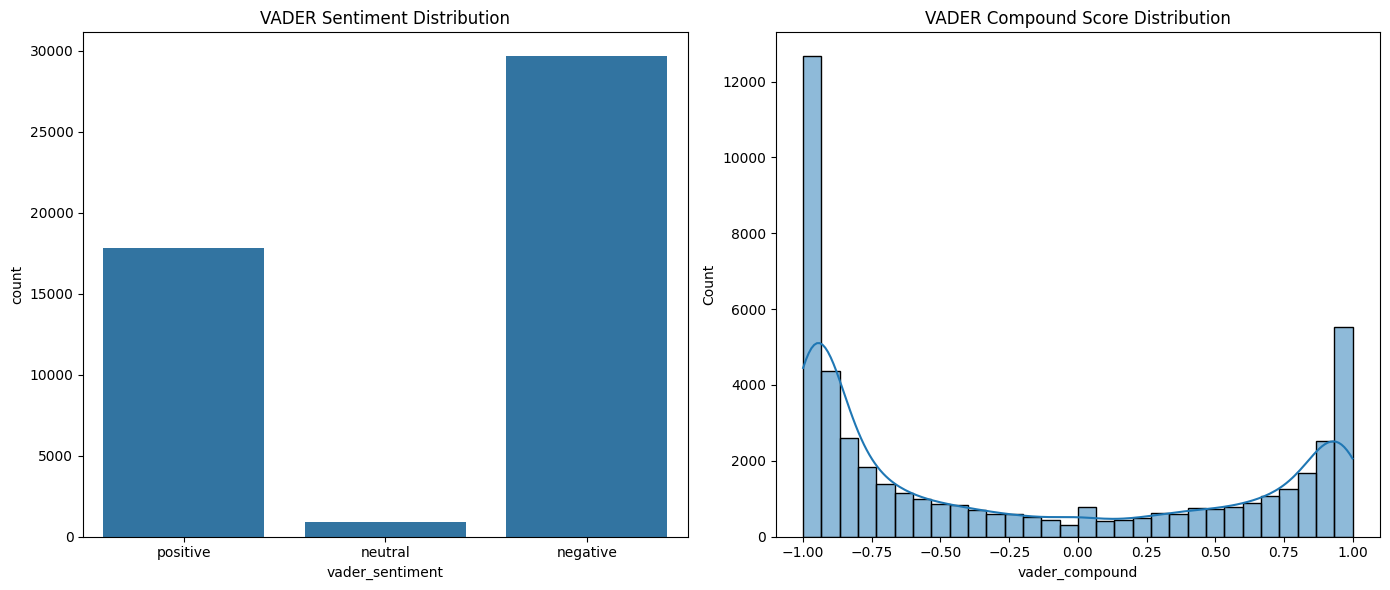

In [11]:
#visualization of the sentiment distribution and the vader component scores side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x='vader_sentiment', data=df_reddit, order=['positive', 'neutral', 'negative'], ax=axes[0])
axes[0].set_title('VADER Sentiment Distribution')
sns.histplot(df_reddit['vader_compound'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('VADER Compound Score Distribution')
plt.tight_layout()
plt.show()

In [12]:
from textblob import TextBlob

def _textblob_scores(text):
    if pd.isna(text) or str(text).strip() == "":
        return pd.Series({'tb_polarity': 0.0, 'tb_subjectivity': 0.0})
    tb = TextBlob(str(text))
    return pd.Series({'tb_polarity': tb.sentiment.polarity, 'tb_subjectivity': tb.sentiment.subjectivity})

# Compute and attach TextBlob scores (uses existing `df_beyondblue` and `text_col`)
tb_df = df_reddit[text_col].apply(_textblob_scores)
df_reddit = pd.concat([df_reddit, tb_df], axis=1)

# Add categorical sentiment label using simple polarity thresholds
df_reddit['tb_sentiment'] = df_reddit['tb_polarity'].apply(
    lambda p: 'positive' if p >= 0.05 else ('negative' if p <= -0.05 else 'neutral')
)

# Quick check
print(df_reddit[[text_col, 'tb_polarity', 'tb_subjectivity', 'tb_sentiment']].head())
print("\nTextBlob sentiment distribution:")
print(df_reddit['tb_sentiment'].value_counts())

                                        post_content  tb_polarity  \
0  I wish someone would just... Just fucking kill...    -0.119479   
1  A friend of mine once described depression as ...    -0.053571   
2  Therapist explained to me that normally people...     0.018044   
3  Everyone says if you're depressed, don't be af...     0.020000   
4  Quiet quitting life I am quiet quitting life a...     0.133550   

   tb_subjectivity tb_sentiment  
0         0.581493     negative  
1         0.839286     negative  
2         0.610440      neutral  
3         0.740000      neutral  
4         0.592857     positive  

TextBlob sentiment distribution:
tb_sentiment
positive    18679
negative    15373
neutral     14352
Name: count, dtype: int64


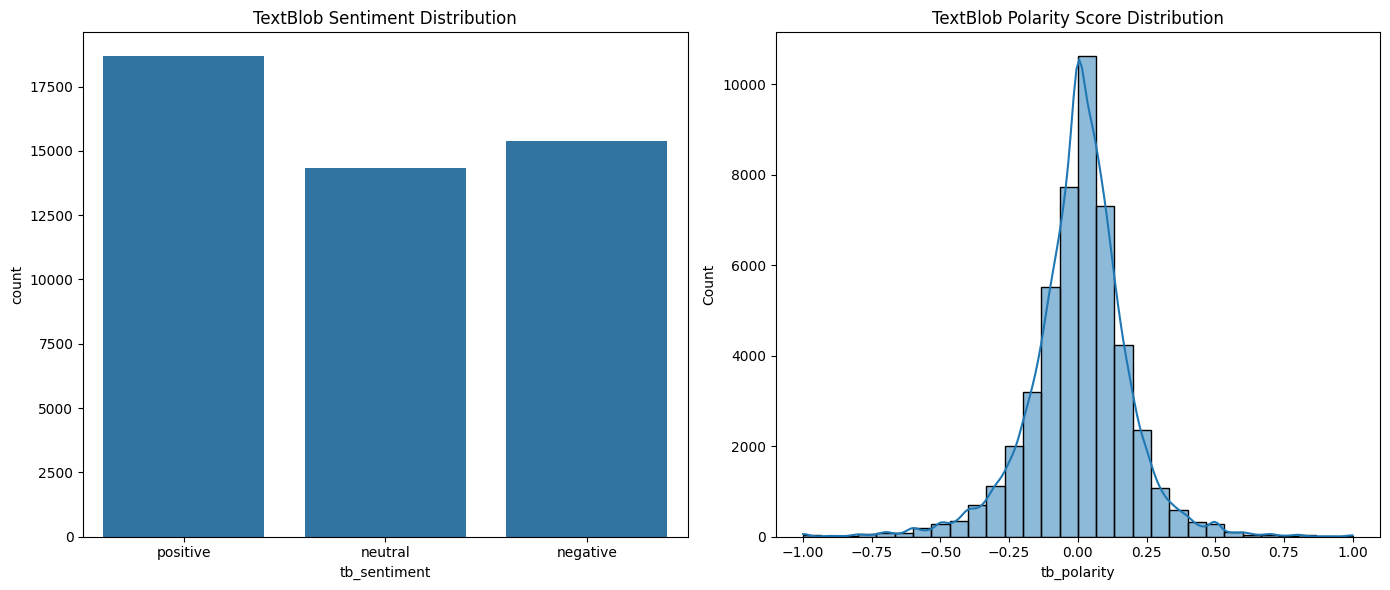

In [13]:
#do the same visualization for TextBlob sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x='tb_sentiment', data=df_reddit, order=['positive', 'neutral', 'negative'], ax=axes[0])
axes[0].set_title('TextBlob Sentiment Distribution')
sns.histplot(df_reddit['tb_polarity'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('TextBlob Polarity Score Distribution')
plt.tight_layout()
plt.show()

Otsu thresholds: -0.48830683593749996 0.3554009765625
Jenks thresholds (internal): -0.4883 0.3536

Counts per method:
col_0       count
otsu_class       
negative    25618
neutral      7192
positive    15594
col_0        count
jenks_class       
negative     25619
neutral       7183
positive     15602
col_0      count
gmm_class       
negative   18924
neutral    17139
positive   12341

Cross-tabulation between methods:
gmm_class   negative  neutral  positive
otsu_class                             
negative       18924     6694         0
neutral            0     7192         0
positive           0     3253     12341


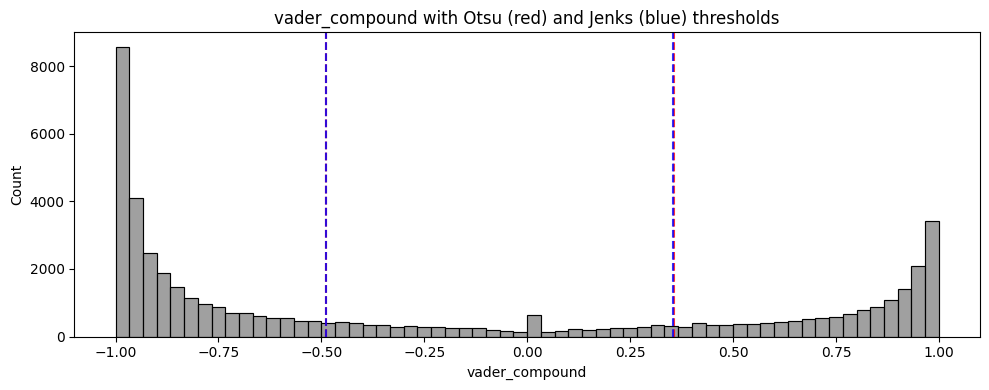

In [14]:
import numpy as np
from sklearn.mixture import GaussianMixture
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

vals = df_reddit['vader_compound'].dropna().values

# 1) Otsu multi-thresholding (exhaustive search for 2 thresholds -> 3 classes)
def otsu_multi_thresholds(data, nbins=256):
    counts, bin_edges = np.histogram(data, bins=nbins, range=(data.min(), data.max()))
    probs = counts.astype(float) / counts.sum()
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    L = len(probs)
    best_sigma = -1
    best_t = (0, 0)
    # two thresholds t1, t2 (indices)
    for t1 in range(1, L - 1):
        w0 = probs[:t1].sum()
        if w0 == 0: continue
        mu0 = (probs[:t1] * bin_centers[:t1]).sum() / w0
        for t2 in range(t1 + 1, L):
            w1 = probs[t1:t2].sum()
            w2 = probs[t2:].sum()
            if w1 == 0 or w2 == 0: continue
            mu1 = (probs[t1:t2] * bin_centers[t1:t2]).sum() / w1
            mu2 = (probs[t2:] * bin_centers[t2:]).sum() / w2
            muT = (probs * bin_centers).sum()
            sigma_b = w0 * (mu0 - muT) ** 2 + w1 * (mu1 - muT) ** 2 + w2 * (mu2 - muT) ** 2
            if sigma_b > best_sigma:
                best_sigma = sigma_b
                best_t = (bin_centers[t1], bin_centers[t2])
    return best_t

otsu_t1, otsu_t2 = otsu_multi_thresholds(vals)
df_reddit['otsu_class'] = pd.cut(df_reddit['vader_compound'],
                                     bins=[-np.inf, otsu_t1, otsu_t2, np.inf],
                                     labels=['negative', 'neutral', 'positive'])

# 2) Jenks (Fisher–Jenks) natural breaks (k=3)
def jenks_breaks(data, n_classes):
    data = np.sort(data)
    n_data = len(data)
    mat1 = np.zeros((n_data + 1, n_classes + 1))
    mat2 = np.zeros((n_data + 1, n_classes + 1))
    for i in range(1, n_classes + 1):
        mat1[0, i] = 1
        mat2[0, i] = 0
        for j in range(1, n_data + 1):
            mat2[j, i] = np.inf
    var = 0.0
    for l in range(1, n_data + 1):
        s1 = s2 = w = 0.0
        for m in range(1, l + 1):
            i3 = l - m + 1
            val = data[i3 - 1]
            s2 += val * val
            s1 += val
            w += 1
            var = s2 - (s1 * s1) / w
            i4 = i3 - 1
            if i4 != 0:
                for j in range(2, n_classes + 1):
                    if mat2[l, j] >= (var + mat2[i4, j - 1]):
                        mat1[l, j] = i3
                        mat2[l, j] = var + mat2[i4, j - 1]
        mat1[l, 1] = 1
        mat2[l, 1] = var
    k = n_data
    kclass = [0.0] * (n_classes + 1)
    kclass[n_classes] = data[-1]
    count_num = n_classes
    while count_num >= 2:
        idx = int(mat1[k, count_num] - 2)
        kclass[count_num - 1] = data[idx]
        k = int(mat1[k, count_num] - 1)
        count_num -= 1
    kclass[0] = data[0]
    return kclass

jenks_bounds = jenks_breaks(vals, 3)  # returns [min, b1, b2, max]
# Use the internal breakpoints (exclude min and max)
jb1, jb2 = jenks_bounds[1], jenks_bounds[2]
df_reddit['jenks_class'] = pd.cut(df_reddit['vader_compound'],
                                      bins=[-np.inf, jb1, jb2, np.inf],
                                      labels=['negative', 'neutral', 'positive'])

# 3) Gaussian Mixture Model (3 components)
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(vals.reshape(-1, 1))
gmm_labels = gmm.predict(df_reddit['vader_compound'].fillna(0).values.reshape(-1, 1))
# order components by mean to get consistent negative/neutral/positive mapping
means = gmm.means_.flatten()
order = np.argsort(means)
label_map = {int(old): new for new, old in enumerate(order)}  # map old->ordered 0..2
ordered_labels = np.array([label_map[int(l)] for l in gmm_labels])
label_names = np.array(['negative', 'neutral', 'positive'])
df_reddit['gmm_class'] = label_names[ordered_labels]

# Quick cross-check summaries
print("Otsu thresholds:", otsu_t1, otsu_t2)
print("Jenks thresholds (internal):", jb1, jb2)
print("\nCounts per method:")
print(pd.crosstab(index=df_reddit['otsu_class'], columns='count'))
print(pd.crosstab(index=df_reddit['jenks_class'], columns='count'))
print(pd.crosstab(index=df_reddit['gmm_class'], columns='count'))

print("\nCross-tabulation between methods:")
print(pd.crosstab(df_reddit['otsu_class'], df_reddit['gmm_class']))

# Optional: quick visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.histplot(df_reddit['vader_compound'], bins=60, kde=False, ax=ax, color='gray')
for thr in [otsu_t1, otsu_t2, jb1, jb2]:
    ax.axvline(thr, linestyle='--', color='red' if thr in (otsu_t1, otsu_t2) else 'blue', alpha=0.8)
ax.set_title('vader_compound with Otsu (red) and Jenks (blue) thresholds')
plt.tight_layout()
plt.show()

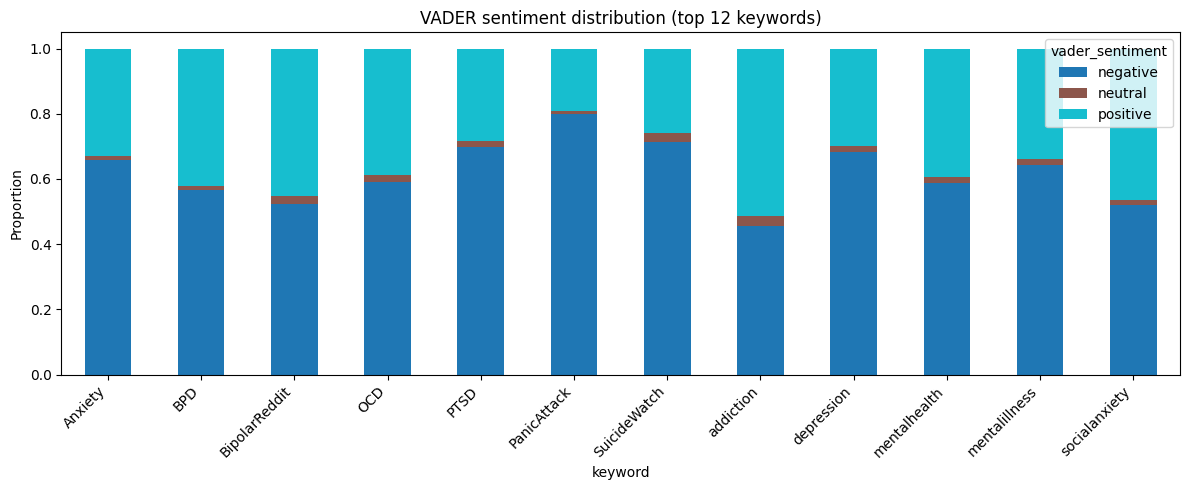

Top 10 topics by VADER positive proportion:
keyword
loneliness       0.555222
addiction        0.513992
socialanxiety    0.465109
BipolarReddit    0.451796
BPD              0.422483
mentalhealth     0.393517
OCD              0.387105
Stress           0.384230
mentalillness    0.340172
Anxiety          0.328880
Name: positive, dtype: float64

Top 10 topics by VADER negative proportion:
keyword
PanicAttack      0.799632
SuicideWatch     0.714376
PTSD             0.698991
depression       0.682108
Anxiety          0.658228
mentalillness    0.643944
Stress           0.603880
OCD              0.590526
mentalhealth     0.587608
BPD              0.567547
Name: negative, dtype: float64


In [18]:
# Sentiment breakdowns by condition/topic and simple clustering of sentiment scores.

# 1) Sentiment distribution by condition (use top N keywords to keep plots readable)
top_n = 12
top_keywords = df_reddit['keyword'].value_counts().nlargest(top_n).index

ct_vader = pd.crosstab(df_reddit.loc[df_reddit['keyword'].isin(top_keywords), 'keyword'],
                       df_reddit.loc[df_reddit['keyword'].isin(top_keywords), 'vader_sentiment'])
ct_vader_norm = ct_vader.div(ct_vader.sum(axis=1), axis=0)

ax = ct_vader_norm.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab10')
ax.set_ylabel('Proportion')
ax.set_title(f'VADER sentiment distribution (top {top_n} keywords)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2) Which topics produce more positive / negative sentiment (rank by proportion)
prop_vader = pd.crosstab(df_reddit['keyword'], df_reddit['vader_sentiment'], normalize='index').fillna(0)
top_positive_topics = prop_vader['positive'].sort_values(ascending=False).head(10)
top_negative_topics = prop_vader['negative'].sort_values(ascending=False).head(10)

print("Top 10 topics by VADER positive proportion:")
print(top_positive_topics)
print("\nTop 10 topics by VADER negative proportion:")
print(top_negative_topics)


In [15]:
#convert the current dataaframe to a csv file
df_reddit.to_csv("reddit_severity.csv", index=False)